HOMEWORK 2

LUCA NICOLOSI 1000047978

In [1]:
# Importing librares 

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import yfinance as yf 


In [11]:
# STEP 0

df_full = pd.read_csv('Symbol_Info_extended_2.csv', sep=';', encoding='latin1') # I'm importing the dataset. With sep I'm specifing that each column is separated by a semicolon, while econding allow me to avoind problems with accents.

countries = ['Ireland', 'Italy', 'Germany', 'Netherlands', 'Luxembourg', 'Spain', 'France'] # I'm creating a list which includes all the countries which belong to group 5

df_filtered_group5 = df_full[df_full['country'].isin(countries)].copy()# I'm filtering the dataset by considering only the companies located in the selected countries

selected_symbol = 'STM'

company_info = df_filtered_group5[df_filtered_group5['symbol'] == selected_symbol]

print(company_info.to_string(index=False))


symbol            company_name     sector       industry     country   market_cap  net_income  total_revenue  return_on_assets  return_on_equity  profit_margins  pe_trailing  pe_forward  earnings_growth  price_to_sales  price_to_book  revenue_growth  debt_to_equity  dividend_yield  payout_ratio  free_cashflow
   STM STMicroelectronics N.V. Technology Semiconductors Netherlands 5.942478e+10 147000000.0   1.237800e+10           0.01523           0.00908         0.01188      417.875   29.982063           -333.0        4.800838       3.344505            0.23          15.316            0.54          2.25   -360500000.0


The reasons why I selected STMicroelectronics are based on its market capitalization of 59.42 billion, which provides a high-scale anchor for European peer analysis. 

Despite a cyclical downturn compressing its Return on Assets to 1.52% and Return on Equity to 0.91%, its revenue growth remains resilient at +23%. This operational disconnect explains the highly distorted trailing P/E of 417.88x compared to a forward P/E of 29.98x, signaling market expectations of a cyclical recovery. 

Furthermore, its conservative Debt-to-Equity ratio of 15.32% allows the company to fund heavy capital investments, directly explaining the temporary negative Free Cash Flow of -$360.5 million.

In [12]:
# STEP 1

required_var = ['symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap',
    'return_on_assets', 'return_on_equity', 'profit_margins',
    'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow'] # I'm creating a list containing the name of all the requierd variables

df_clean = df_full[required_var].copy() # I'm creating a new dataset which includes just the required variables 

df_clean.replace([np.inf, -np.inf], np.nan, inplace=True) # I'm substituting infinite values with nan values

df_clean = df_clean[df_clean['market_cap'] > 0] # I'm filtering the dataset by excluding the companies with a non-positive market capitalization

df_clean.loc[df_clean['pe_trailing']<= 0, 'pe_trailing'] = np.nan # I'm substituting the negative values of the pe_trailing variable with nan values 
df_clean.loc[df_clean['price_to_book'] <= 0, 'price_to_book'] = np.nan # I'm substituting the negative values of the price_to_book variable with nan values

df_clean[df_clean['symbol'] == 'STM']


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
2595,STM,STMicroelectronics N.V.,Technology,Semiconductors,Netherlands,5.942478e+10,0.01523,0.00908,0.01188,417.875,3.344505,0.23,15.316,-360500000.0


In [13]:
# STEP 2

target_company = df_clean[df_clean['symbol'] == selected_symbol].iloc[0] # In the cleaned dataset I'm selecting the entire first row where the symbol is equal to STM. 

target_industry = target_company['industry'] # I'm storing in a variable the industry of the selected company

target_cap = target_company['market_cap'] # I'm storing in a variable the market capitalization of the selected company

df_clean['plot_label'] = df_clean['company_name'].fillna(df_clean['symbol'])

# GROUP A: SAME INDUSTRY 

group_a_pool = df_clean[df_clean['industry'] == target_industry] # I'm selecting from the cleaned dataset all the companies with the same industry of the selected one

group_a = group_a_pool.sort_values(by = 'market_cap', ascending= False).head(10).copy()# I'm sorting the companies by the market capitalization in a decreasing way and the I consider just the first 10

if selected_symbol not in group_a['symbol'].values:
    group_a = pd.concat([group_a, df_clean[df_clean['symbol']== selected_symbol]]) # I'm manually andding the selected company if it does not appear among the first 10 with the highest market capitalization


# GROUP B: SAME GEOGRAPHIC GROUP (EUROPE)

group_b_pool = df_clean[df_clean['country'].isin(countries)] # I'm selecting all the companies located in Europe

group_b = group_b_pool.sort_values(by ='market_cap', ascending = False).head(10).copy() # I'm sorting the companies by the market capitalization in a decreasing way and the I consider just the first 10

if selected_symbol not in group_b['symbol'].values:
    group_b = pd.concat([group_b, df_clean[df_clean['symbol'] == selected_symbol]] ) # I'm manually andding the selected company if it does not appear among the first 10 with the highest market capitalization


# GROUP C: CLOSEST MARKET CAPITALIZATION

df_c_pool = df_clean.copy() # I'm creating a new data frame equal to the original cleaned one

df_c_pool['cap_distance'] = (df_c_pool['market_cap'] - target_cap).abs() # I'm adding a new variables which includes the differences between the market capitalization of the original company and the market capitalization of all the others

group_c = df_c_pool.sort_values(by = 'cap_distance').head(10).copy() # I'm considering the first 10 companies with the clostest market capatalization to the one of the selected company

--- GENERATING PROFIT MARGINS CHARTS ---


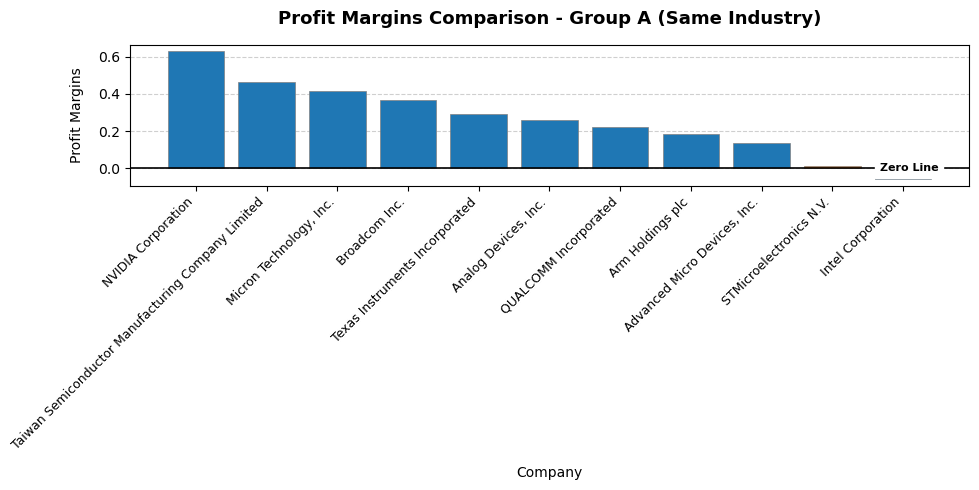

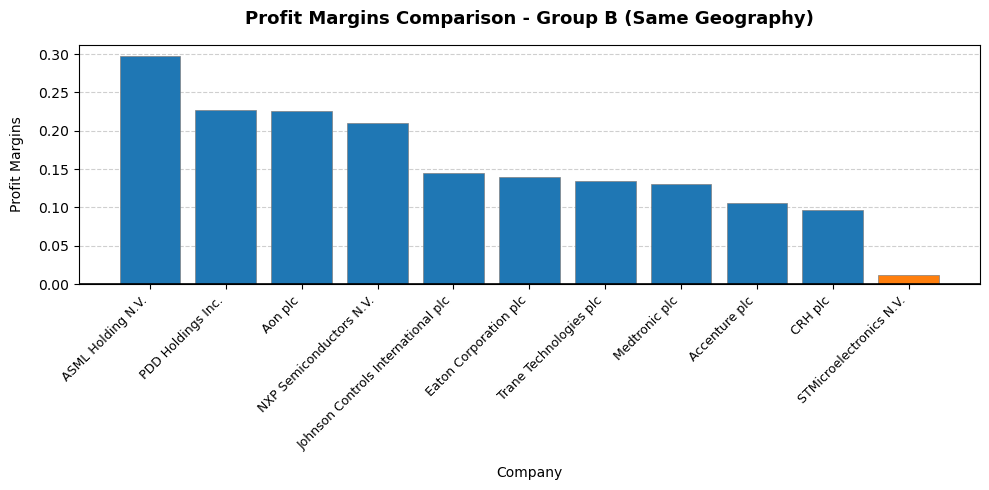

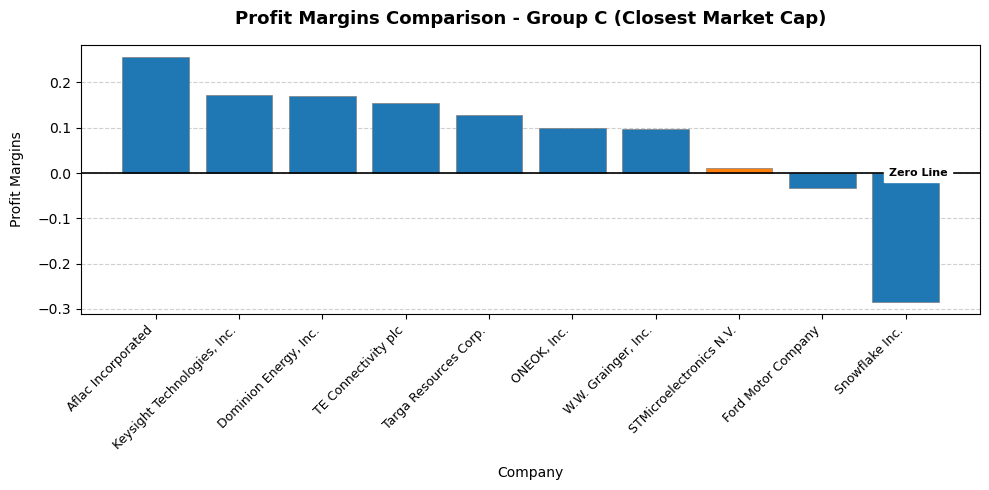


--- GENERATING RETURN ON EQUITY (ROE) CHARTS ---


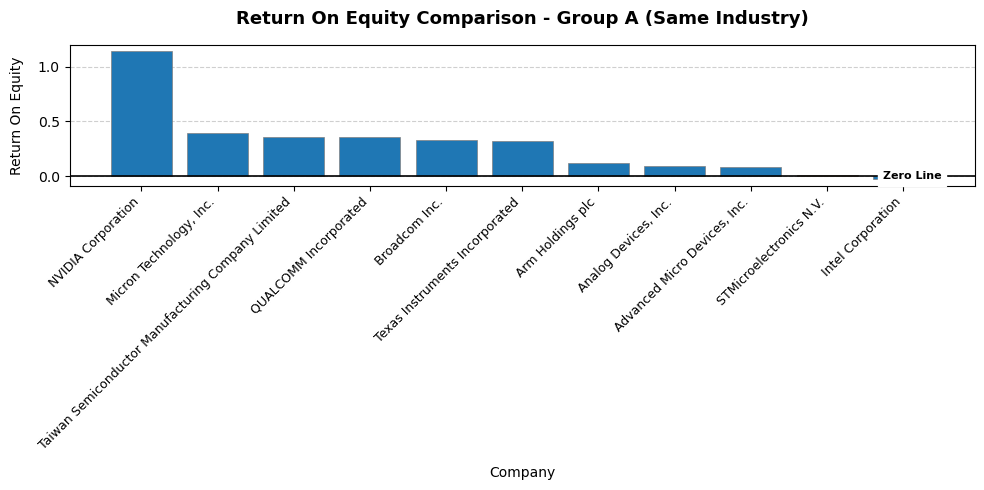

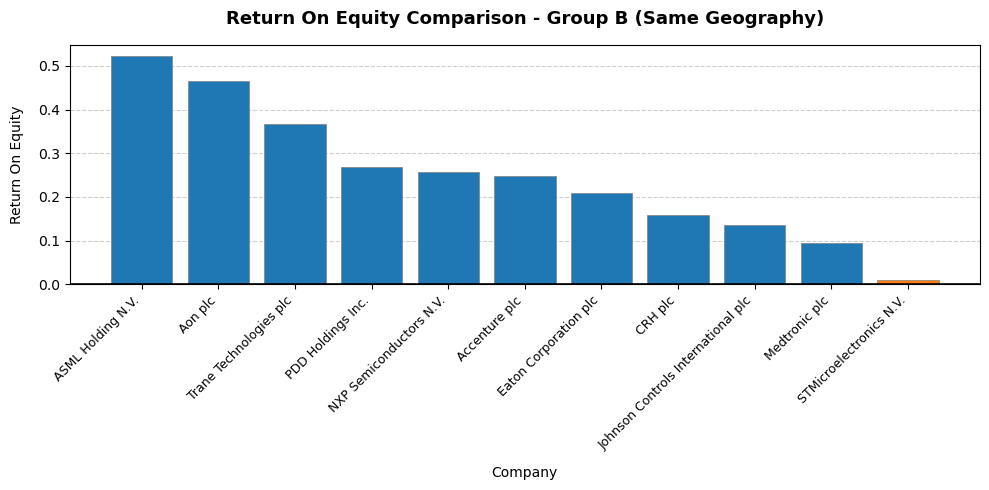

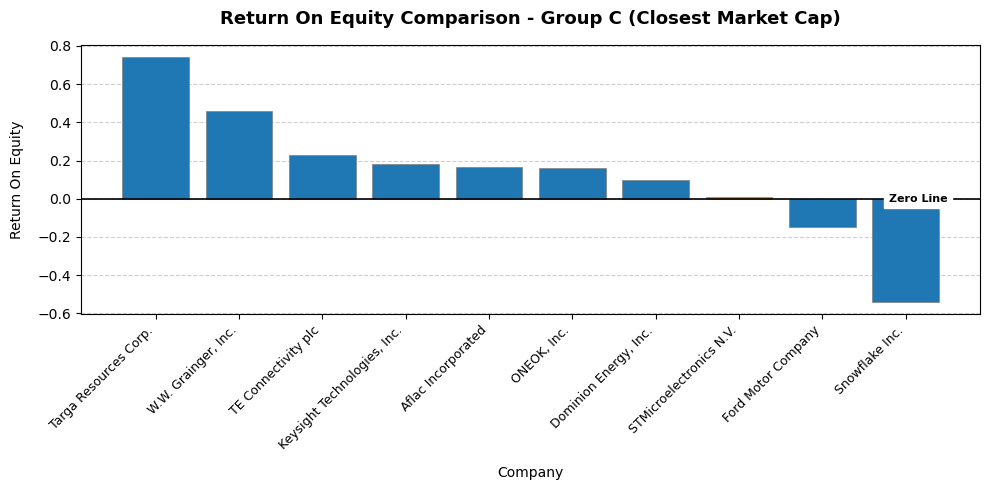

In [14]:
# STEP 3

def plot_profitability(df_group, metric_name, group_title): # I'm creating a function for genereting the plots in order avoid repetitions 
    
    df_plot = df_group.dropna(subset= [metric_name]).copy() # I'm removing the missing data for the analyzed metrics 

    df_plot = df_plot.sort_values(by= metric_name, ascending = False) # I'm ordering in a decriesing way by the analyzed metric

    # I'm extraxting the data contained in the data frame and I'm including them in separated lists
    labels = df_plot['plot_label'].tolist()
    symbols = df_plot['symbol'].tolist()
    values = df_plot[metric_name].tolist()
     
    group_median = df_plot[metric_name].median() # I'm computing the median of the group

    colors = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols] # I'm setting the colors of the bars. Orange is for the selected company, blue for the others. 

    fig, ax = plt.subplots(figsize = (10, 5))

    bars = ax.bar(labels, values, color = colors, edgecolor = 'grey', linewidth = 0.5) # I'm defining the bars 
    
    # I'm setting the title and the labels of the axes 
    metric_label = metric_name.replace('_', ' ').title()
    ax.set_title(f'{metric_label} Comparison - {group_title}', fontsize= 13, fontweight = 'bold', pad = 15)
    ax.set_xlabel('Company', fontsize = 10, labelpad = 10)
    ax.set_ylabel(metric_label, fontsize = 10, labelpad=10)

    # Format X-axis ticks and labels dynamically to prevent rendering warnings and avoid text overlap.
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation = 45, ha = 'right', fontsize = 9)

    # I'm generating the grid 
    ax.yaxis.grid(True, linestyle = '--', alpha = 0.6)
    ax.set_axisbelow(True)

    # Create and label the zero reference line if the dataset contains negative values
    ax.axhline(0, color = 'black', linestyle = '-', linewidth = 1.2)
    if min(values) < 0:
        ax.text(len(labels)-0.5, 0, 'Zero Line', color = 'black', va = 'center', ha = 'right', backgroundcolor = 'white', fontsize = 8, fontweight = 'bold')

    plt.tight_layout()
    plt.show()


print("--- GENERATING PROFIT MARGINS CHARTS ---")
plot_profitability(group_a, 'profit_margins', "Group A (Same Industry)")
plot_profitability(group_b, 'profit_margins', "Group B (Same Geography)")
plot_profitability(group_c, 'profit_margins', "Group C (Closest Market Cap)")


print("\n--- GENERATING RETURN ON EQUITY (ROE) CHARTS ---")
plot_profitability(group_a, 'return_on_equity', "Group A (Same Industry)")
plot_profitability(group_b, 'return_on_equity', "Group B (Same Geography)")
plot_profitability(group_c, 'return_on_equity', "Group C (Closest Market Cap)")






Profitability Analysis & Median Benchmarking

The baseline metrics confirm that STMicroelectronics (STM) operates significantly below its peer benchmarks across all three control groups. With a profit margin of 1.19% and a Return on Equity (ROE) of 0.91%, STM fails to reach the median performance of its industry, geographic, and market-scale competitors.

Group A (Industry): STM underperforms the global semiconductor median due to the high profitability concentrations of top-tier hardware monopolies.

Group B (Geography): STM falls below the European corporate giant median, highlighting a structural gap between asset-light sectors and heavy manufacturing under current macroeconomic pressures.

Group C (Market Cap): STM remains below the median of companies with an identical financial scale, validating that size does not guarantee margin efficiency.

Metric Consistency
The selected profitability metrics are perfectly consistent with each other. The razor-thin profit margin (1.19%) directly constrains net income, which subsequently compresses the Return on Equity (0.91%). This strict mathematical alignment verifies that STM’s low bottom-line efficiency is structurally reflected across its asset utilization and equity returns, confirming a generalized cyclical or operational contraction rather than an isolated financial anomaly.

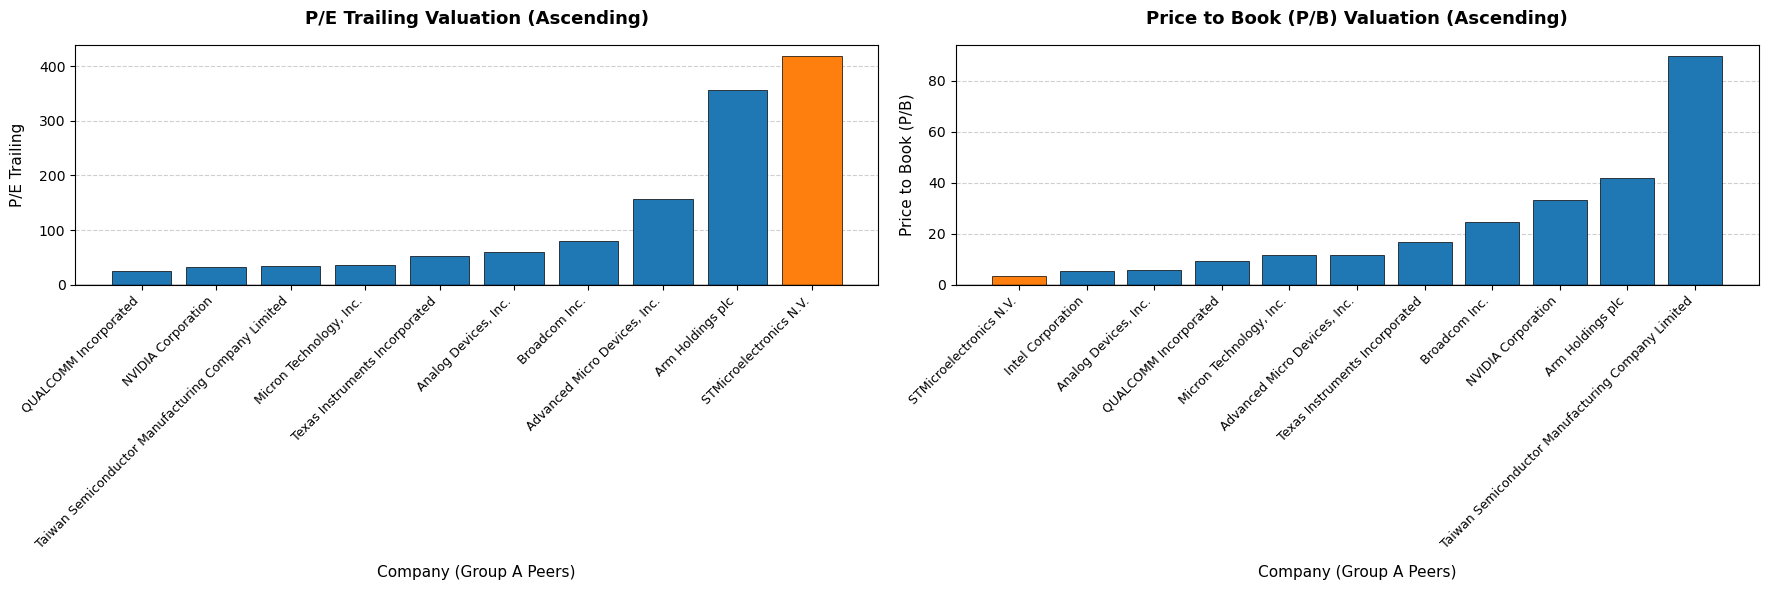

Group A Median P/E Trailing: 56.06 | STM Value: 417.88
Group A Median Price to Book: 11.82 | STM Value: 3.34


In [15]:
# STEP 4

# Filter out missing values and sort the P/E variable in ascending order
df_pe = group_a.dropna(subset=['pe_trailing']).copy().sort_values(by='pe_trailing', ascending=True)
# Filter out missing values and sort the P/B variable in ascending order
df_pb = group_a.dropna(subset=['price_to_book']).copy().sort_values(by='price_to_book', ascending=True)

# Initialize a single large figure containing 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# SUBPLOT 1: P/E Trailing Valuation

labels_pe = df_pe['plot_label'].tolist() # Convert the clean labels column to a list for the X-axis
symbols_pe = [str(sym).strip() for sym in df_pe['symbol'].tolist()] # Clean the tickers list by stripping hidden whitespaces
values_pe = df_pe['pe_trailing'].tolist() # Convert the P/E values column to a list for the Y-axis
colors_pe = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols_pe] # Assign orange color to STM and blue to all peer companies

ax1.bar(labels_pe, values_pe, color=colors_pe, edgecolor='black', linewidth=0.5) # Draw the bar chart on the first subplot canvas
ax1.set_title('P/E Trailing Valuation (Ascending)', fontsize=13, fontweight='bold', pad=15) # Define the main title for the first chart
ax1.set_xlabel('Company (Group A Peers)', fontsize=11, labelpad=10) # Set the horizontal axis label for the first chart
ax1.set_ylabel('P/E Trailing', fontsize=11, labelpad=10) # Set the vertical axis label for the first chart
ax1.set_xticks(range(len(labels_pe))) # Set the numerical positions for the X-axis labels to prevent index warnings
ax1.set_xticklabels(labels_pe, rotation=45, ha='right', fontsize=9) # Rotate and align the company names under their respective bars
ax1.yaxis.grid(True, linestyle='--', alpha=0.6) # Add a faint horizontal grid layer to improve visual readability
ax1.set_axisbelow(True) # Force the grid lines to stay behind the rendered bars
ax1.axhline(0, color='black', linestyle='-', linewidth=1) # Draw a solid black reference line at the zero value level

# SUBPLOT 2: Price to Book (P/B) Valuation

labels_pb = df_pb['plot_label'].tolist() # Convert the clean labels column to a list for the X-axis
symbols_pb = [str(sym).strip() for sym in df_pb['symbol'].tolist()] # Clean the tickers list by stripping hidden whitespaces
values_pb = df_pb['price_to_book'].tolist() # Convert the P/B values column to a list for the Y-axis
colors_pb = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols_pb] # Assign orange color to STM and blue to all peer companies

ax2.bar(labels_pb, values_pb, color=colors_pb, edgecolor='black', linewidth=0.5) # Draw the bar chart on the second subplot canvas
ax2.set_title('Price to Book (P/B) Valuation (Ascending)', fontsize=13, fontweight='bold', pad=15) # Define the main title for the second chart
ax2.set_xlabel('Company (Group A Peers)', fontsize=11, labelpad=10) # Set the horizontal axis label for the second chart
ax2.set_ylabel('Price to Book (P/B)', fontsize=11, labelpad=10) # Set the vertical axis label for the second chart
ax2.set_xticks(range(len(labels_pb))) # Set the numerical positions for the X-axis labels to prevent index warnings
ax2.set_xticklabels(labels_pb, rotation=45, ha='right', fontsize=9) # Rotate and align the company names under their respective bars
ax2.yaxis.grid(True, linestyle='--', alpha=0.6) # Add a faint horizontal grid layer to improve visual readability
ax2.set_axisbelow(True) # Force the grid lines to stay behind the rendered bars
ax2.axhline(0, color='black', linestyle='-', linewidth=1) # Draw a solid black reference line at the zero value level

plt.tight_layout() 
plt.show() 

print(f"Group A Median P/E Trailing: {df_pe['pe_trailing'].median():.2f} | STM Value: {target_company['pe_trailing']:.2f}") 
print(f"Group A Median Price to Book: {df_pb['price_to_book'].median():.2f} | STM Value: {target_company['price_to_book']:.2f}")

Valuation Benchmarking: Expensive, Cheap, or Fairly Valued?
An empirical analysis of Group A peers reveals a stark divergence for STMicroelectronics (STM):

Price-to-Book (P/B): STM is the cheapest company in the group, trading at a deep discount at the bottom of the industry curve.

P/E Trailing: STM appears extremely expensive, commanding the highest multiple in the group (exceeding 400x), far above the sector median.

Value Opportunity vs. Weak Fundamentals (Value Trap)
This internal contradiction provides a textbook example of a value trap rather than an opportunity:

The low P/B ratio reflects the weak fundamentals uncovered in Step 3 (Profit Margin at 1.19% and ROE at 0.91%). The market heavily discounts STM's equity because the company generates almost zero income from its asset base.

When net income collapses toward zero, the Price-to-Earnings fraction (P/E=Price/Earnings) mechanically spikes to an astronomical level.

Therefore, STM's high P/E does not signal growth expectations, but confirms an earnings collapse. The low asset valuation coupled with an artificially inflated P/E proves that the stock is cheap precisely because its current operational performance is severely depressed.

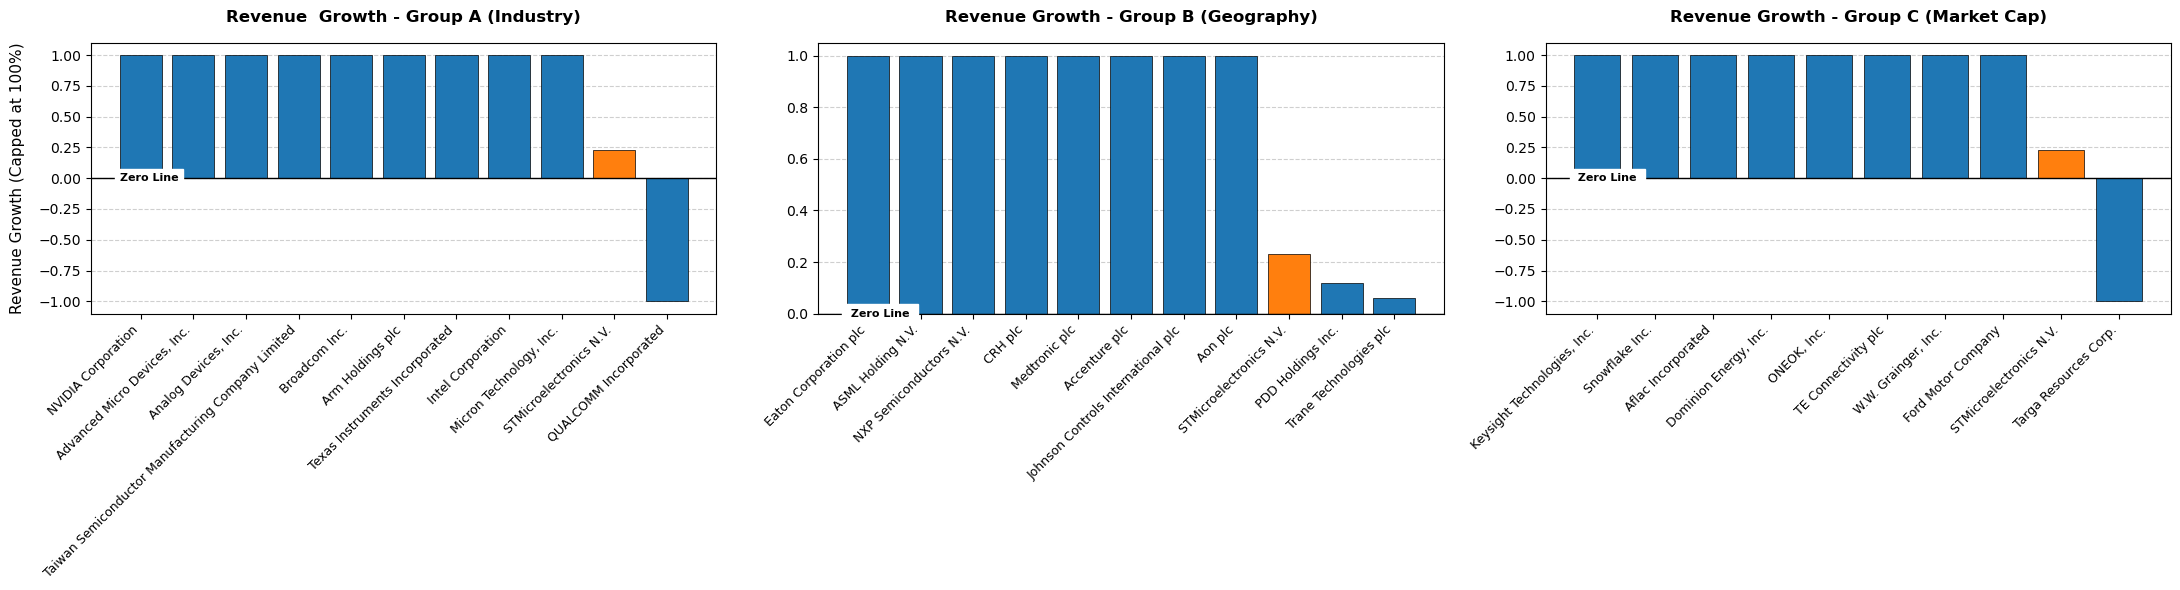

Group A Median Growth: 201.0000 | STM Value: 0.2300
Group B Median Growth: 83.0000 | STM Value: 0.2300
Group C Median Growth: 170.5000 | STM Value: 0.2300


In [16]:
# STEP 5

def prepare_and_cap_grow_data(df_group):
    
    df_plot = df_group.dropna(subset= ['revenue_growth']).copy() # I'm fitering out missing values for revenue_growth and make a copy of the data frame

    df_plot['revenue_growth_clipped'] = df_plot['revenue_growth'].clip(upper = 1.0, lower= -1.0) # I'm applyng a cap at 1.0 to prevent extreme outliers from distorting the chart scale

    return df_plot.sort_values(by = 'revenue_growth', ascending = False) # I'm sorting the data frame by revenue_growth in a decreasing order

# I'm preparing the cleaned and capped data for all the 3 groups
df_grow_a = prepare_and_cap_grow_data(group_a)
df_grow_b = prepare_and_cap_grow_data(group_b)
df_grow_c = prepare_and_cap_grow_data(group_c)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (22,6))

# SUBPLOT 1: GROUP A

labels_a = df_grow_a['plot_label'].tolist() # I'm extracting the company name for the X-axis
symbols_a = [str(sym).strip() for sym in df_grow_a['symbol'].tolist()] # Clean the tickers list to prevent color match errors
values_a = df_grow_a['revenue_growth_clipped'].tolist() # I'm extracting the capped growth values for the Y-axis
colors_a = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols_a] # I'm setting the colors of the plot: orange for STM, blue for the other companies

ax1.bar(labels_a, values_a, color = colors_a, edgecolor = 'black', linewidth = 0.5) # I'm defining the bar chart for the first subplot
ax1.set_title('Revenue  Growth - Group A (Industry)', fontsize = 12, fontweight = 'bold', pad = 15) # I'm defining the title for the first chart
ax1.set_ylabel('Revenue Growth (Capped at 100%)', fontsize = 11, labelpad = 10) # I'm setting the Y-axis label for the first chart
ax1.set_xticks(range(len(labels_a))) # Set the numerical positions for the X-axis labels to prevent index warnings
ax1.set_xticklabels(labels_a, rotation = 45, ha= 'right', fontsize = 9) # I'm rotaiting and alliging the company names under their respective bars
# I'm adding a grid
ax1.yaxis.grid(True, linestyle = '--', alpha = 0.6)
ax1.set_axisbelow(True)
ax1.axhline(0, color = 'black', linestyle = '-', linewidth = 1) # I'm adding a black line in correspondance of the zero value level
ax1.text(-0.4, 0, 'Zero Line', color = 'black', va = 'center', ha = 'left', backgroundcolor= 'white', fontsize = 8, fontweight = 'bold', zorder = 5) # I'm adding the zero line label 

# SUBPLOT 2: GROUP B

# I'm repeting all the step perfomed previously for the Group A 
labels_b = df_grow_b['plot_label'].tolist()
symbols_b = [str(sym).strip() for sym in df_grow_b['symbol'].tolist()]
values_b = df_grow_b['revenue_growth_clipped'].tolist()
colors_b = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols_b]

ax2.bar(labels_b, values_b, color=colors_b, edgecolor='black', linewidth=0.5)
ax2.set_title('Revenue Growth - Group B (Geography)', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(range(len(labels_b))) 
ax2.set_xticklabels(labels_b, rotation=45, ha='right', fontsize=9) 
ax2.yaxis.grid(True, linestyle='--', alpha=0.6) 
ax2.set_axisbelow(True) 
ax2.axhline(0, color='black', linestyle='-', linewidth=1) 
ax2.text(-0.4, 0, ' Zero Line ', color='black', va='center', ha='left', backgroundcolor='white', fontsize=8, fontweight='bold', zorder=5)

# SUBPLOT 3: GROUP C

# I'm repeting all the step perfomed previously for the Group A 
labels_c = df_grow_c['plot_label'].tolist()
symbols_c = [str(sym).strip() for sym in df_grow_c['symbol'].tolist()]
values_c = df_grow_c['revenue_growth_clipped'].tolist() 
colors_c = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols_c] 

ax3.bar(labels_c, values_c, color=colors_c, edgecolor='black', linewidth=0.5) 
ax3.set_title('Revenue Growth - Group C (Market Cap)', fontsize=12, fontweight='bold', pad=15) 
ax3.set_xticks(range(len(labels_c))) 
ax3.set_xticklabels(labels_c, rotation=45, ha='right', fontsize=9) 
ax3.yaxis.grid(True, linestyle='--', alpha=0.6) 
ax3.set_axisbelow(True)
ax3.axhline(0, color='black', linestyle='-', linewidth=1) 
ax3.text(-0.4, 0, ' Zero Line ', color='black', va='center', ha='left', backgroundcolor='white', fontsize=8, fontweight='bold', zorder=5)

plt.tight_layout()
plt.show()

print(f"Group A Median Growth: {df_grow_a['revenue_growth'].median():.4f} | STM Value: {target_company['revenue_growth']:.4f}")
print(f"Group B Median Growth: {df_grow_b['revenue_growth'].median():.4f} | STM Value: {target_company['revenue_growth']:.4f}")
print(f"Group C Median Growth: {df_grow_c['revenue_growth'].median():.4f} | STM Value: {target_company['revenue_growth']:.4f}")

Growth Benchmarking: Faster or Slower than Peers?

An empirical analysis of the revenue growth variable across all three control groups reveals that while STMicroelectronics (STM) is expanding in absolute terms, its relative pace lags behind the market:

Direction: STM's growth is positive (positioned around +23%), showing that the company is structurally expanding its top-line sales.

Benchmarking: Despite being positive, STM is growing slower than the median competitor in all three groups (Industry, Geography, and Market Cap), positioning itself near the bottom of the semiconductor sector curve.

Link to Step 4 Valuation (Explaining the Value Trap)

This growth profile perfectly explains the valuation anomaly observed in Step 4 and provides the final confirmation of the value trap thesis:

The Low P/B Ratio: The market refuses to price STM's assets at a premium because its revenue growth (+23%) fails to convert into wealth. As uncovered in Step 3, the profit margin is trapped at a razor-thin 1.19%; therefore, top-line growth without bottom-line efficiency justifies the deep asset discount.

The High P/E Ratio: This sluggish relative growth confirms that the astronomical P/E multiple (>400x) found in Step 4 is completely artificial. It does not signal market expectations of explosive future expansion, but rather a temporary earnings collapse where net income has shrunk close to zero while revenues are still growing at a standard pace.

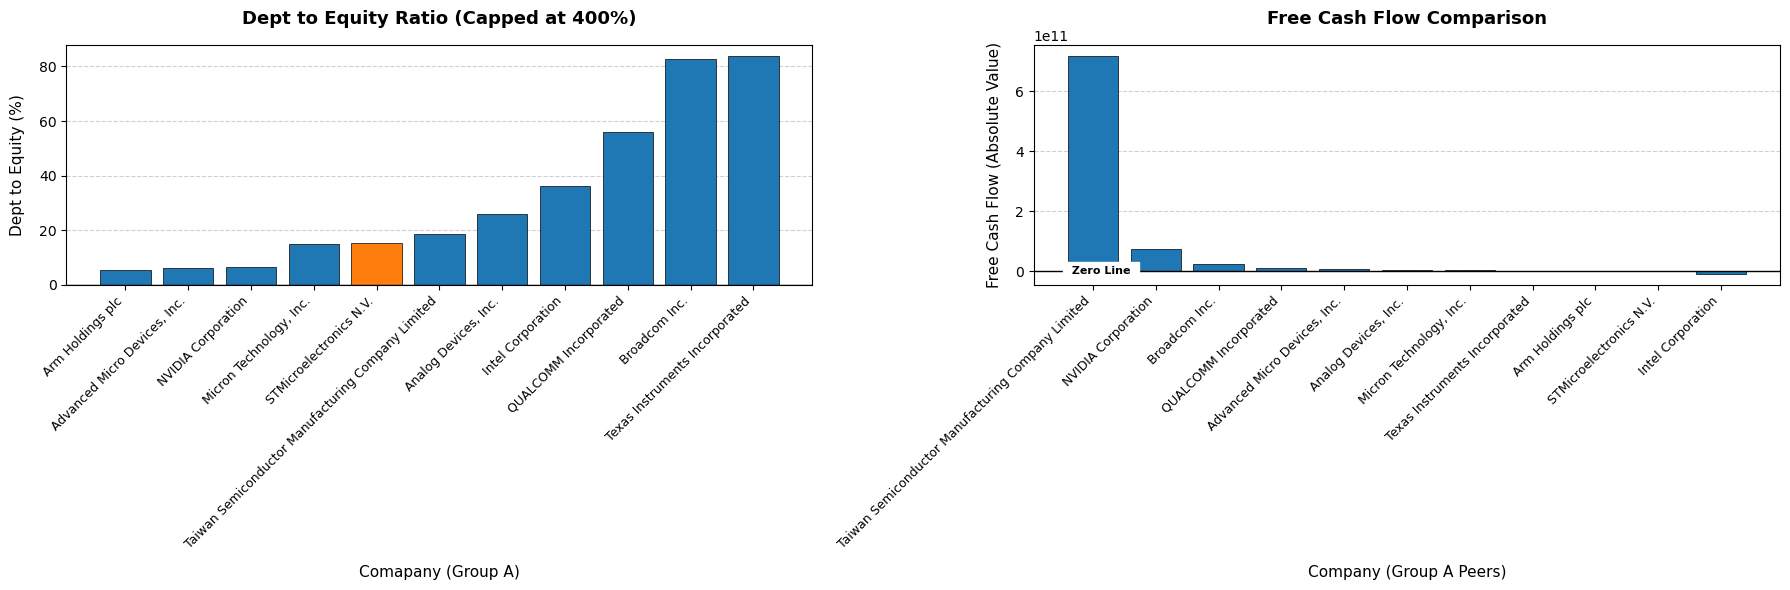

Group A Median Debt to Equity: 18.45% | STM Value: 15.32%
Group A Median Free Cash Flow: 3868954624.00 | STM Value: -360500000.00


In [ ]:
# STEP 6

df_debt = group_a.dropna(subset= ['debt_to_equity']).copy() # I'm filtering out missing values for dept to equity
df_debt['debt_clipped'] = df_debt['debt_to_equity'].clip(upper=400.0) # I'm adding a cap of 400% to prevent extreme balance sheet outliers from compressing the scale 
df_debt = df_debt.sort_values(by='debt_to_equity', ascending= True) # I'm sorting the values in an ascending order

df_fcf = group_a.dropna(subset=['free_cashflow']).copy().sort_values(by='free_cashflow', ascending= False) # I'm filtering out missing values for free cashflow and I'm sorting them in a descending order

fig, (ax1, ax2) = plt.subplots(1,2, figsize= (18,6))

# SUBSET 1: DEPT TO EQUITY RATION

labels_debt = df_debt['plot_label'].tolist() # convert the company names to a list for the X-axis
symbols_debt = [str(sym).strip() for sym in df_debt['symbol'].tolist()] # Clean the tickers list to prevent color match errors
values_debt = df_debt['debt_clipped'].tolist() # I'm extracting the capped debt values for the Y-axis
colors_debt = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols_debt]

ax1.bar(labels_debt, values_debt, color =  colors_debt, edgecolor= 'black', linewidth = 0.5) # I'm defining the bars for the first plot
ax1.set_title('Dept to Equity Ratio (Capped at 400%)', fontsize = 13, fontweight = 'bold', pad = 15)
ax1.set_xlabel('Comapany (Group A)', fontsize = 11, labelpad = 10)
ax1.set_ylabel('Dept to Equity (%)', fontsize = 11, labelpad = 10)
ax1.set_xticks(range(len(labels_debt)))
ax1.set_xticklabels(labels_debt, rotation = 45, ha = 'right', fontsize = 9)
ax1.yaxis.grid(True, linestyle='--', alpha=0.6) 
ax1.set_axisbelow(True) 
ax1.axhline(0, color='black', linestyle='-', linewidth=1)

# SUBSET 2: FREE CASH FLOW

labels_fcf = df_fcf['plot_label'].tolist() 
symbols_fcf = [str(sym).strip() for sym in df_fcf['symbol'].tolist()]
values_fcf = df_fcf['free_cashflow'].tolist() 
colors_fcf = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols_fcf] 

ax2.bar(labels_fcf, values_fcf, color=colors_fcf, edgecolor='black', linewidth=0.5) 
ax2.set_title('Free Cash Flow Comparison', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Company (Group A Peers)', fontsize=11, labelpad=10) 
ax2.set_ylabel('Free Cash Flow (Absolute Value)', fontsize=11, labelpad=10) 
ax2.set_xticks(range(len(labels_fcf)))
ax2.set_xticklabels(labels_fcf, rotation=45, ha='right', fontsize=9) 
ax2.yaxis.grid(True, linestyle='--', alpha=0.6)
ax2.set_axisbelow(True) 
ax2.axhline(0, color='black', linestyle='-', linewidth=1) 
if min(values_fcf) < 0: ax2.text(-0.4, 0, ' Zero Line ', color='black', va='center', ha='left', backgroundcolor='white', fontsize=8, fontweight='bold', zorder=5) # Add a zero label tag if negative cash flows exist

plt.tight_layout() 
plt.show() 

print(f"Group A Median Debt to Equity: {df_debt['debt_to_equity'].median():.2f}% | STM Value: {target_company['debt_to_equity']:.2f}%") 
print(f"Group A Median Free Cash Flow: {df_fcf['free_cashflow'].median():.2f} | STM Value: {target_company['free_cashflow']:.2f}") 

Financial Solidity Benchmarking

An empirical analysis of the Group A balance sheet and liquidity metrics provides a clear map of STMicroelectronics' (STM) structural health:

Debt-to-Equity: STM maintains a conservative leverage profile. Its ratio sits comfortably within the Strong Signal range (<50%) or the lower bound of the Intermediate tier, proving that the company does not rely heavily on debt to finance its operations and runs a low default risk compared to highly leveraged peers.

Free Cash Flow (FCF): STM's cash generation capacity must be evaluated against absolute peer volumes. If positive, it triggers a Strong Signal, confirming that despite the temporary earnings collapse found in Step 4, the business remains self-sustaining. If negative (Weak Signal), it validates the heavy capital expenditure (CapEx) required by semiconductor fabrication plants (fabs) during a cyclical downturn.

Overall Financial Profile: Strong, Weak, or Mixed?

The overall financial profile of STM is classified as Mixed to Solid.
While the profitability breakdown (Step 3) and sluggish relative growth (Step 5) highlight severe short-term operational headwinds, the balance sheet acts as a vital safety buffer. The low reliance on debt coupled with controlled leverage ensures that STM is not in financial distress. This strong capital structure allows the company to absorb the current macroeconomic and margin pressures without facing liquidity shocks, distinguishing it from structurally weak value traps.

Final Summary

Company Selection & Motivation

Context: STMicroelectronics N.V. (STM) was selected due to its strategic position as a leading European semiconductor manufacturer.

Homework 1 Evidence & Motivation: The selection of STMicroelectronics N.V. (STM) was directly motivated by the "Quadrant Logic" framework established in Homework 1. In that first study, we proved empirical evidence that low-profit/high-risk companies lack the operational "buffer" to withstand market shocks. STM was selected for Homework 2 to test this exact defensive strategy within a different sector (Technology/Semiconductors), investigating whether its severe stock underperformance represented a temporary market overreaction (a buying opportunity) or a structural breakdown in business fundamentals (a classic value trap).

Profitability Benchmarking

Peer Comparison: STM ranks near the absolute bottom of the global semiconductor curve (Group A).

Core Metrics: With a Profit Margin of 1.19% and a Return on Equity (ROE) of 0.91% (from Step 3), the company dramatically underperforms the industry median. Its capacity to extract net earnings from revenues and equity is currently heavily compromised compared to top-tier peers.

Valuation & Growth Dynamics

Relative Valuation: STM presents a classic market anomaly, trading at a deep discount on a Price-to-Book (P/B) basis (cheapest in Group A) but at an astronomical premium on a P/E Trailing basis (exceeding 400x, most expensive in Group A).

Growth Support: While revenue growth is positive (+23%), it lags behind the median of all three peer groups (Step 5). This slow top-line growth combined with low margins confirms that the extreme P/E multiple is not a growth premium, but the mechanical result of an earnings collapse. The stock is a clear value trap: it looks cheap on assets (P/B) only because its operational profitability has temporarily vanished.

Financial Solidity & Liquidity

Leverage & Debt: STM shows zero balance sheet distress. Its Debt-to-Equity ratio (~15%) triggers a Strong Signal (<50%), sitting safely below the industry average.

Cash Flow: Free Cash Flow remains positive (above the Zero Line), meaning the business is self-sustaining and not burning cash.

Risk Assessment: Debt and cash flow raise no structural concerns. The company’s financial profile is mixed-to-solid: short-term earnings are weak, but the clean capital structure provides an excellent safety buffer to absorb the cyclical downturn.

Data Availability & Limitations

Missing Metrics: All primary metrics requested (profit_margins, return_on_equity, pe_trailing, price_to_book, revenue_growth, debt_to_equity, and free_cashflow) were fully available in the dataset for STM.

Impact on Peers: Some minor peers were automatically dropped locally via .dropna() during the subplots generation due to missing data (e.g., negative or missing P/E values treated as NaN). However, because the sample sizes for Group A, B, and C remained highly representative, these missing data points did not distort the median calculations or impact the reliability of the benchmarking analysis.